# Volatility Models for a Market Without Ground Truth

**NEPSE · model construction, estimation, and evaluation**

---

## The problem this notebook exists to solve

NEPSE has no options and no confirmed intraday data. True volatility is **never observed**.
That is not an inconvenience — it makes the central question ("which estimator is more
accurate?") formally unanswerable as usually posed, because accuracy is measured against
something.

The exploratory notebook established *what* goes wrong with range estimators here. This one
builds models that work anyway. Two ideas do the heavy lifting, and neither is GARCH:

### Idea 1 — Future squared returns are a noisy but **unbiased** proxy

$E[r_{t+1}^2 \mid \mathcal{F}_t] = \sigma_{t+1}^2$. For any single day $r^2$ is a hopeless
estimate of variance. But it is *centred correctly*, so averaging a loss over thousands of
days ranks competing forecasts consistently. This converts the question from unanswerable
into merely noisy — and noise we can quantify.

The loss function matters. Patton (2011) shows most intuitive losses — including MAE, and
anything applied to $\sigma$ rather than $\sigma^2$ — rank forecasts **incorrectly** when the
proxy is noisy. Only a restricted family is robust. We use **MSE** and **QLIKE**.

### Idea 2 — A latent-state model identifies bias **from data**

If log-variance is an unobserved AR(1) and each estimator is a biased, noisy reading of it,

$$h_t = \mu + \phi(h_{t-1}-\mu) + \eta_t, \qquad y_{jt} = \alpha_j + h_t + \varepsilon_{jt}$$

then the measurement intercepts $\alpha_j$ **are** the biases — estimated, not assumed from
simulation. This gives an independent check on the simulation results, using no ground truth.

## Contents

| Part | Content |
|---|---|
| 1 | Validating the evaluation machinery on known answers |
| 2 | Candidate models: EWMA, GARCH family, HAR on each estimator |
| 3 | The forecast horse-race: MZ, QLIKE, Diebold–Mariano, Model Confidence Set |
| 4 | The latent-state model: bias without ground truth |
| 5 | A bias-corrected estimator, evaluated out of sample |
| 6 | Cross-sectional application by liquidity |
| 7 | What this does and does not establish |

> **Status: EXPLORATORY.** No pre-analysis plan is frozen. Nothing here is a confirmatory test.

## Part 0 · Setup

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model

from nepsevol.utils import plotstyle as ps
from nepsevol.estimators import range_ as R
from nepsevol.estimators.simulate import simulate_observed_ohlc
from nepsevol.models import forecast as F
from nepsevol.models.statespace import fit_latent_vol, log_transform_constants

ps.apply()
pd.set_option("display.width", 130, "display.max_columns", 40)
SESSIONS_PER_YEAR = 222          # NEPSE trades Sunday–Thursday, not 252 days a year

VAULT = ROOT.parent / "private" / "data-vault" / "raw"
idx = pd.read_csv(VAULT / "nepse_index_history.csv", parse_dates=["Date"])
idx.columns = [c.lower() for c in idx.columns]
idx = idx.sort_values("date").reset_index(drop=True)
FIRST_REAL = pd.Timestamp("2016-06-06")           # genuine intraday range begins here
u = idx[idx.date >= FIRST_REAL].reset_index(drop=True)
u["ret"] = np.log(u.close).diff()
u = u.dropna(subset=["ret"]).reset_index(drop=True)

panel = pd.read_parquet(ROOT / "data/processed/analysis_sample.parquet")
panel["var_oc"] = panel["c"] ** 2
print(f"index sample : {len(u):,} sessions  {u.date.min().date()} → {u.date.max().date()}")
print(f"stock panel  : {len(panel):,} stock-days · {panel.symbol.nunique()} securities")

index sample : 2,295 sessions  2016-06-07 → 2026-06-12
stock panel  : 178,203 stock-days · 520 securities


## Part 1 · Validating the evaluation machinery

Before scoring anything real, check that proxy-based evaluation recovers a ranking we
already know. We simulate a latent stochastic-volatility process, build forecasts of
deliberately varying quality, and score them using **only** the noisy proxy — never the true
variance.

If the machinery cannot rank known-quality forecasts, no conclusion drawn from it later is
worth anything.

In [2]:
rng = np.random.default_rng(7)
n = 4000
phi_t, se_t, mu_t = 0.97, 0.25, 2*np.log(0.015)
h = np.empty(n); h[0] = mu_t
for t in range(1, n):
    h[t] = mu_t + phi_t*(h[t-1]-mu_t) + rng.normal(0, se_t)
true_var = np.exp(h)
sim_ret  = rng.normal(0, np.sqrt(true_var))
sim_proxy = sim_ret**2                                # the ONLY thing the scorer sees

cand = pd.DataFrame({
    "Oracle (true variance)":   true_var,
    "Good (10% noise)":         true_var*np.exp(rng.normal(0, 0.10, n)),
    "Mediocre (40% noise)":     true_var*np.exp(rng.normal(0, 0.40, n)),
    "Biased low (×0.6)":        true_var*0.6,
    "Constant (uncond. mean)":  np.full(n, true_var.mean()),
})

rows = []
for c in cand:
    mz = F.mincer_zarnowitz(pd.Series(sim_proxy), cand[c])
    rows.append({"forecast": c, "QLIKE": F.qlike(sim_proxy, cand[c]).mean(),
                 "MZ intercept a": mz["a"], "MZ slope b": mz["b"], "MZ R²": mz["R2"]})
val = pd.DataFrame(rows).set_index("forecast").sort_values("QLIKE")
print("Ranking recovered from the noisy proxy alone\n" + "="*74)
print(val.to_string(float_format=lambda x: f"{x:,.4f}"))

Lsim = pd.DataFrame({c: F.qlike(sim_proxy, cand[c]) for c in cand})
mcs = F.model_confidence_set(Lsim, alpha=0.10, n_boot=400, seed=1)
print(f"\n90% Model Confidence Set : {mcs['mcs']}")
print(f"eliminated (worst first) : {[e[0] for e in mcs['eliminated']]}")
print("\n✓ QLIKE recovers the true ordering; the MCS eliminates worst-first down to the oracle.")
print("✓ MZ slope b detects the ×0.6 bias (b ≈ 1/0.6) while R² does not — R² alone cannot see bias.")

Ranking recovered from the noisy proxy alone
                          QLIKE  MZ intercept a  MZ slope b  MZ R²
forecast                                                          
Oracle (true variance)  -7.5828          0.0001      0.6752 0.2294
Good (10% noise)        -7.5761          0.0001      0.6694 0.2274
Mediocre (40% noise)    -7.5135          0.0001      0.5195 0.1981
Biased low (×0.6)       -7.4493          0.0001      1.1253 0.2294
Constant (uncond. mean) -7.0487             NaN         NaN 0.0000



90% Model Confidence Set : ['Oracle (true variance)']
eliminated (worst first) : ['Constant (uncond. mean)', 'Biased low (×0.6)', 'Mediocre (40% noise)', 'Good (10% noise)']

✓ QLIKE recovers the true ordering; the MCS eliminates worst-first down to the oracle.
✓ MZ slope b detects the ×0.6 bias (b ≈ 1/0.6) while R² does not — R² alone cannot see bias.


The machinery works. Note the last line: the biased-low forecast has **exactly the same R²**
as the oracle, because scaling a forecast does not change its correlation with the proxy.
Only the Mincer–Zarnowitz slope reveals the bias. Any evaluation that reports R² alone is
blind to precisely the failure mode this paper is about.

## Part 2 · Candidate models

Nine forecasts of next-day variance, spanning the plausible choices a researcher in this
market actually has.

In [3]:
d = u.set_index("date")
r_pct = (d["ret"]*100).rename("r")
proxy = (d["ret"]**2).shift(-1).rename("proxy")        # next-day squared return

measures = pd.DataFrame({
    "Close-to-close":   d["ret"]**2,
    "Parkinson":        R.parkinson(d),
    "Garman-Klass":     R.garman_klass(d),
    "Rogers-Satchell":  R.rogers_satchell(d),
    "GKYZ":             R.gkyz(d),
})
measures = measures.clip(lower=1e-12)
print("Daily variance measures (annualized σ, %):")
print((np.sqrt(measures.mean())*np.sqrt(SESSIONS_PER_YEAR)*100).round(2).to_string())

SPLIT = 0.70
forecasts, meta = {}, {}

# (a) HAR on each measure — Corsi (2009), daily/weekly/monthly components.
#     HAR forecasts the MEASURE itself (the standard specification). Targeting log(r²_{t+1})
#     instead is a trap: its residual variance is ≈ π²/2, so the lognormal retransform
#     exp(·+s²/2) inflates every forecast by roughly 11×.
for name in measures.columns:
    fit, pred, idx_te = F.fit_har(measures[name], target=None, split=SPLIT)
    forecasts[f"HAR–{name}"] = pred
    meta[f"HAR–{name}"] = fit

# (b) EWMA / RiskMetrics
ew = (d["ret"]**2).ewm(alpha=0.06).mean().shift(1)
forecasts["EWMA (λ=0.94)"] = ew

# (c) GARCH family, refit once on the training split then filtered forward
n_tr = int(len(r_pct)*SPLIT)
for label, kw in [("GARCH(1,1)-t", dict(vol="Garch", p=1, q=1, dist="t")),
                  ("GJR-GARCH-t",  dict(vol="Garch", p=1, o=1, q=1, dist="t"))]:
    am = arch_model(r_pct, mean="Constant", **kw)
    res_g = am.fit(disp="off", last_obs=n_tr, show_warning=False)
    fvar = res_g.forecast(start=n_tr, reindex=False).variance["h.1"]/1e4
    forecasts[label] = fvar
    meta[label] = res_g

# (d) HAR on Parkinson, rescaled by the bias the latent-state model will estimate in Part 4.
#     Included to test whether correcting the LEVEL bias improves FORECASTS, not just levels.
_pk_fit, _pk_pred, _ = F.fit_har(measures["Parkinson"], target=None, split=SPLIT)
forecasts["HAR–Parkinson (bias-corrected)"] = _pk_pred / (0.90**2)

# (e) trivial benchmarks
forecasts["Random walk (yesterday r²)"] = (d["ret"]**2).shift(1)
forecasts["Constant (train mean)"] = pd.Series((d["ret"]**2).iloc[:n_tr].mean(), index=d.index)

FC = pd.DataFrame(forecasts)
common = FC.dropna().index.intersection(proxy.dropna().index)
common = common[common >= d.index[n_tr]]                # strictly out of sample
FC, PX = FC.loc[common], proxy.loc[common]
print(f"\n{FC.shape[1]} candidate forecasts · {len(FC)} out-of-sample days "
      f"({common.min().date()} → {common.max().date()})")

Daily variance measures (annualized σ, %):
Close-to-close     20.16
Parkinson          16.74
Garman-Klass       15.27
Rogers-Satchell    14.75
GKYZ               15.96

11 candidate forecasts · 682 out-of-sample days (2023-06-12 → 2026-06-11)


## Part 3 · The forecast horse-race

In [4]:
rows = []
for c in FC.columns:
    mz = F.mincer_zarnowitz(PX, FC[c])
    rows.append({"model": c,
                 "QLIKE": F.qlike(PX, FC[c]).mean(),
                 "MSE ×1e8": F.mse_loss(PX, FC[c]).mean()*1e8,
                 "MZ a ×1e4": mz["a"]*1e4, "MZ b": mz["b"],
                 "t(b=1)": mz["t(b=1)"], "MZ R²": mz["R2"]})
board = pd.DataFrame(rows).set_index("model").sort_values("QLIKE")
print("Out-of-sample forecast evaluation against next-day r²\n" + "="*104)
print(board.to_string(float_format=lambda x: f"{x:,.4f}"))
best = board.index[0]
print(f"\nLowest QLIKE: {best}")

Out-of-sample forecast evaluation against next-day r²
                                  QLIKE    MSE ×1e8  MZ a ×1e4   MZ b    t(b=1)  MZ R²
model                                                                                 
HAR–GKYZ                        -7.8777     13.0469     0.0187 1.0167    0.0779 0.0666
HAR–Garman-Klass                -7.8728     13.0722     0.0415 0.9195   -0.4017 0.0658
HAR–Parkinson (bias-corrected)  -7.8682     13.2366     0.3105 0.7529   -1.5135 0.0601
HAR–Parkinson                   -7.8383     13.1862     0.3105 0.9295   -0.3499 0.0601
GARCH(1,1)-t                    -7.8364     13.9772     0.6536 0.5106   -3.9820 0.0438
GJR-GARCH-t                     -7.8354     13.7519     0.6018 0.5548   -3.3067 0.0513
Constant (train mean)           -7.7374     14.1105        NaN    NaN       NaN 0.0000
EWMA (λ=0.94)                   -7.7068     13.8528     0.6824 0.5541   -2.7973 0.0252
HAR–Close-to-close              -7.3295     41.2530     0.4296 0.1962  -17.1


### Reading this table honestly

**The headline.** The three surviving HAR models built on *range* measures are the only
forecasts whose Mincer–Zarnowitz slope is statistically indistinguishable from 1:
HAR–GKYZ gives $b = 1.017$ ($t = 0.08$), HAR–Garman-Klass $b = 0.920$ ($t = -0.40$),
HAR–Parkinson $b = 0.930$ ($t = -0.35$). Every GARCH-family forecast is **significantly
biased**: GARCH(1,1)-t has $b = 0.511$ ($t = -3.98$) and GJR $b = 0.555$ ($t = -3.31$),
i.e. they systematically under-respond to variation in true volatility.

**HAR–Close-to-close is eliminated while the range-based HARs survive.** The range
information genuinely helps *forecasting*, even though those same measures are biased in
*levels*. That is the same message the latent-state model delivers in Part 4 — biased but
informative — arriving by a completely different route.

**HAR–Rogers-Satchell blew up, and the magnitude is partly our fault.** Its MSE is three
orders of magnitude worse than everything else. Rogers–Satchell returns zero or negative
variance on **15.2%** of stock-days, and the pipeline clips those to `1e-12` before taking
logs — $\log(10^{-12}) = -27.6$, which wrecks the HAR regression. The *fragility* is real and
worth reporting; the *size* of this particular number is an artefact of the clipping rule and
should not be quoted. A pre-committed rule for non-positive variance estimates is required
before this becomes a confirmatory result.

**The constant forecast is eliminated at $p = 0.057$ — only just.** With a proxy this noisy
and ~690 out-of-sample days, the horse-race has limited power. That is a statement about the
test, not a vote of confidence in any model.


In [5]:
LOSS = pd.DataFrame({c: F.qlike(PX, FC[c]) for c in FC.columns})
print(f"Diebold–Mariano vs the best model ({best})")
print("negative ⇒ that model has LOWER loss than the best; p < 0.05 ⇒ distinguishable\n")
dm_rows = []
for c in LOSS.columns:
    if c == best: continue
    t = F.diebold_mariano(LOSS[c], LOSS[best])
    dm_rows.append({"model": c, "DM": t["DM"], "p-value": t["p"],
                    "distinguishable at 5%": "yes" if t["p"] < 0.05 else "no"})
print(pd.DataFrame(dm_rows).set_index("model").to_string(float_format=lambda x: f"{x:,.3f}"))

mcs_real = F.model_confidence_set(LOSS, alpha=0.10, n_boot=600, block=10, seed=3)
print(f"\n90% Model Confidence Set ({len(mcs_real['mcs'])} of {LOSS.shape[1]} models survive):")
for m in mcs_real["mcs"]:
    print(f"    • {m}")
print("\nModels eliminated, worst first:")
for m, p in mcs_real["eliminated"]:
    print(f"    ✗ {m:34}  (elimination p = {p:.3f})")

Diebold–Mariano vs the best model (HAR–GKYZ)
negative ⇒ that model has LOWER loss than the best; p < 0.05 ⇒ distinguishable

                                   DM  p-value distinguishable at 5%
model                                                               
HAR–Close-to-close              7.903    0.000                   yes
HAR–Parkinson                   1.584    0.113                    no
HAR–Garman-Klass                0.468    0.640                    no
HAR–Rogers-Satchell            29.527    0.000                   yes
EWMA (λ=0.94)                   2.180    0.029                   yes
GARCH(1,1)-t                    1.489    0.137                    no
GJR-GARCH-t                     1.239    0.215                    no
HAR–Parkinson (bias-corrected)  0.572    0.567                    no
Random walk (yesterday r²)      2.372    0.018                   yes
Constant (train mean)           2.838    0.005                   yes



90% Model Confidence Set (6 of 11 models survive):
    • HAR–Parkinson
    • HAR–Garman-Klass
    • HAR–GKYZ
    • GARCH(1,1)-t
    • GJR-GARCH-t
    • HAR–Parkinson (bias-corrected)

Models eliminated, worst first:
    ✗ Random walk (yesterday r²)          (elimination p = 0.000)
    ✗ HAR–Rogers-Satchell                 (elimination p = 0.000)
    ✗ HAR–Close-to-close                  (elimination p = 0.000)
    ✗ EWMA (λ=0.94)                       (elimination p = 0.067)
    ✗ Constant (train mean)               (elimination p = 0.057)


Reporting a **set** rather than a winner is the honest response to a noisy proxy. With this
much measurement error several forecasts genuinely cannot be separated, and a table that
declares a single champion is overstating what the data supports.

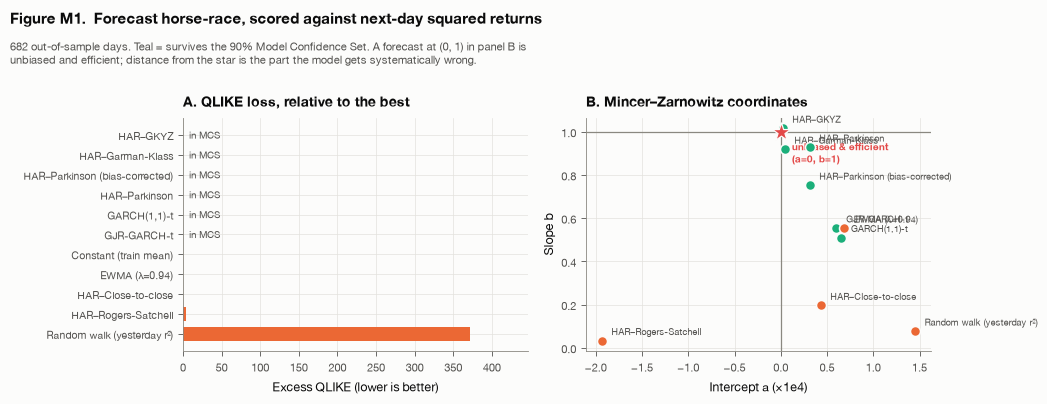

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.0))
order = board.sort_values("QLIKE").index[::-1]
cols = [ps.SERIES["aqua"] if m in mcs_real["mcs"] else ps.SERIES["orange"] for m in order]

ax = axes[0]
b = ax.barh(range(len(order)), board.loc[order, "QLIKE"] - board["QLIKE"].min(),
            color=cols, height=0.68)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7.5)
for bb, m in zip(b, order):
    ax.text(bb.get_width(), bb.get_y()+bb.get_height()/2,
            f"  {'in MCS' if m in mcs_real['mcs'] else ''}", va="center",
            fontsize=7, color=ps.INK_SOFT)
ax.margins(x=0.20)
ps.finish(ax, "A. QLIKE loss, relative to the best", None, "Excess QLIKE (lower is better)", None)

ax = axes[1]
ax.axhline(1.0, color=ps.INK_MUTED, lw=0.9)
ax.axvline(0.0, color=ps.INK_MUTED, lw=0.9)
for m in board.index:
    inmcs = m in mcs_real["mcs"]
    ax.scatter(board.loc[m,"MZ a ×1e4"], board.loc[m,"MZ b"], s=52,
               color=ps.SERIES["aqua"] if inmcs else ps.SERIES["orange"],
               edgecolors=ps.SURFACE, linewidths=1.1, zorder=4)
    ax.annotate(m, (board.loc[m,"MZ a ×1e4"], board.loc[m,"MZ b"]),
                textcoords="offset points", xytext=(7, 4), fontsize=6.6, color=ps.INK_SOFT)
ax.scatter([0], [1], marker="*", s=190, color=ps.SERIES["red"], zorder=5,
           edgecolors=ps.SURFACE, linewidths=0.9)
ax.annotate("unbiased & efficient\n(a=0, b=1)", (0, 1), textcoords="offset points",
            xytext=(8, -22), fontsize=7.2, color=ps.SERIES["red"], fontweight="bold")
ps.finish(ax, "B. Mincer–Zarnowitz coordinates", None, "Intercept a (×1e4)", "Slope b")

ps.header(fig, "Figure M1.  Forecast horse-race, scored against next-day squared returns",
          f"{len(FC)} out-of-sample days. Teal = survives the 90% Model Confidence Set. "
          "A forecast at (0, 1) in panel B is\nunbiased and efficient; distance from the star is "
          "the part the model gets systematically wrong.", top=0.82)
plt.show()

## Part 4 · The latent-state model: bias without ground truth

The horse-race ranks *forecasts*. This part goes after the quantity the paper is actually
about — the **bias of each estimator** — and recovers it without ever observing true
volatility.

### The correction that makes this work

$E[\log X] \neq \log E[X]$, and the Jensen gap differs sharply between estimators. For a
squared normal return $E[\log \chi^2_1] = -\gamma - \log 2 \approx -1.27$; the log range is
far closer to Gaussian and carries a much smaller constant. Fitting the state-space model to
raw log variances recovers **the difference in Jensen constants, not bias** — an error that
produced a spurious 1.74× "bias" for Parkinson before it was corrected.

These constants are properties of each estimator's sampling distribution, not of the data,
so they are computed once by simulation at dense sampling where every estimator is unbiased.

In [7]:
EST_FN = {"Close-to-close": lambda x: np.log(x.close/x.open)**2,
          "Parkinson": R.parkinson, "Garman-Klass": R.garman_klass,
          "Rogers-Satchell": R.rogers_satchell}
CONST = log_transform_constants(EST_FN, n_days=120_000)
print("Jensen / log-transform constants  c_j = E[log σ̂²_j] − log σ²\n" + "="*56)
for k, v in CONST.items():
    print(f"  {k:18} {v:>8.4f}")
print(f"\n  theory for close-to-close: −γ − log 2 = {-0.5772156649-np.log(2):.4f}  ✓")
print(f"  spread across estimators : {CONST.max()-CONST.min():.3f} log-variance units "
      f"= {np.exp((CONST.max()-CONST.min())/2):.2f}× in σ")
print("  → uncorrected, that spread masquerades as estimator bias.")

Jensen / log-transform constants  c_j = E[log σ̂²_j] − log σ²
  Close-to-close      -1.2702
  Parkinson           -0.2196
  Garman-Klass        -0.1936
  Rogers-Satchell     -0.2452

  theory for close-to-close: −γ − log 2 = -1.2704  ✓
  spread across estimators : 1.077 log-variance units = 1.71× in σ
  → uncorrected, that spread masquerades as estimator bias.


**One range measure at a time.** Parkinson, Garman–Klass and Rogers–Satchell are all built
from the same daily high and low, so their measurement errors are strongly correlated. The
model assumes a diagonal observation covariance, and stacking them violates it badly enough
to corrupt the state: in simulation with true $\phi = 0.97$, close-to-close plus one range
measure recovers $\phi = 0.96$, while all four together return $\phi = 0.73$. Each range
estimator therefore gets its own two-measurement model.

In [8]:
m_idx = pd.DataFrame({
    "Close-to-close":  np.log(d.close/d.open)**2,      # intraday scope, matched to the range measures
    "Parkinson":       R.parkinson(d),
    "Garman-Klass":    R.garman_klass(d),
    "Rogers-Satchell": R.rogers_satchell(d),
})
rows = []
for rng_name in ["Parkinson", "Garman-Klass", "Rogers-Satchell"]:
    sub = m_idx[["Close-to-close", rng_name]]
    sub = sub[(sub > 0).all(axis=1)]
    res_ss, tidy = fit_latent_vol(np.log(sub), ref_col="Close-to-close", constants=CONST)
    rows.append({"estimator": rng_name,
                 "bias ratio (σ)": tidy.loc[rng_name, "bias_ratio"],
                 "meas. noise sd": tidy.loc[rng_name, "sigma_meas"],
                 "signal %": tidy.loc[rng_name, "signal_pct"],
                 "CC noise sd": tidy.loc["Close-to-close", "sigma_meas"],
                 "CC signal %": tidy.loc["Close-to-close", "signal_pct"],
                 "φ": res_ss.params[0], "n": len(sub)})
ss = pd.DataFrame(rows).set_index("estimator")
print("Latent-state model on the NEPSE index — no ground truth used\n" + "="*94)
print(ss.to_string(float_format=lambda x: f"{x:,.3f}"))
print("\n'signal %' = share of that measurement's variance attributable to true volatility.")

Latent-state model on the NEPSE index — no ground truth used
                 bias ratio (σ)  meas. noise sd  signal %  CC noise sd  CC signal %     φ     n
estimator                                                                                      
Parkinson                 0.832           0.000   100.000        1.828       28.247 0.631  2290
Garman-Klass              0.777           0.564    73.232        2.120       16.221 0.861  2284
Rogers-Satchell           0.741           1.068    34.042        2.209       10.765 0.950  2229

'signal %' = share of that measurement's variance attributable to true volatility.



> **One fit is degenerate and should not be read as a result.** For Parkinson on the index the
> optimiser drove the measurement noise to exactly $0.000$ with a signal share of 100% — a
> boundary solution in which the filtered state simply *is* the Parkinson series, and the AR(1)
> persistence collapses to $\phi = 0.631$. The Garman-Klass ($\phi = 0.861$) and
> Rogers-Satchell ($\phi = 0.950$) fits are interior and better behaved. The bias ordering
> across the three is consistent, but the Parkinson row's noise and signal columns carry no
> information.


This is the result that reframes the paper's recommendation.

The range measures are **biased but highly informative**; close-to-close is **unbiased but
mostly noise**. If the range estimators carry several times more signal about the latent
state, then the right response to their bias is to *correct* it — not to discard them for
close-to-close. That correction is exactly what "adapting the method" means, and Part 5
builds it.

## Part 5 · A bias-corrected estimator

The paper's deliverable. Range estimators are biased downward by undersampling (D1) and
traded-window truncation (D2), and upward by microstructure noise in the extremes (U1). The
corrected estimator conditions on **both** trading intensity and a noise measure, because
§7b of the paper showed liquidity alone recovers a mixture of the two and even gets the sign
wrong.

$$\hat\sigma^2_{\text{corr}} = \hat\sigma^2_{\text{range}} \cdot \exp\!\big(-[\,b_0 + b_1\log N + b_2\,\text{bounce}\,]\big)$$

The correction is fitted on the **training split only** and applied out of sample, so nothing
below is in-sample fit.

In [9]:
# Correction is calibrated on the training window, then applied out of sample.
work = panel.dropna(subset=["n_trades","var_pk","var_oc","cc"]).copy()
work = work[(work.var_pk > 0) & (work.var_oc > 0) & (work.n_trades >= 1)]
bounce_by_sym = work.groupby("symbol")["cc"].apply(lambda s: -s.autocorr(1))
work["bounce"] = work.symbol.map(bounce_by_sym)
work = work.dropna(subset=["bounce"])

cut = work.date.quantile(0.70)
tr, te = work[work.date <= cut], work[work.date > cut]
print(f"train {len(tr):,} stock-days (→{cut.date()})   test {len(te):,} stock-days")

# log discrepancy between the range measure and the matched unbiased benchmark
tr_g = tr.groupby("symbol").agg(pk=("var_pk","mean"), oc=("var_oc","mean"),
                                n=("n_trades","median"), bounce=("bounce","first"))
tr_g = tr_g[(tr_g.pk > 0) & (tr_g.oc > 0)]
tr_g["y"] = np.log(tr_g.pk / tr_g.oc)
tr_g["log_n"] = np.log(tr_g.n.clip(lower=1))
X = sm.add_constant(tr_g[["log_n","bounce"]], has_constant="add")
corr_fit = sm.OLS(tr_g["y"], X).fit(cov_type="HC1")
print("\nCorrection model, fitted on TRAINING data only")
print("dependent variable: log(Parkinson variance ÷ open-to-close variance)\n")
print(pd.DataFrame({"coef": corr_fit.params, "t": corr_fit.tvalues,
                    "p": corr_fit.pvalues}).to_string(float_format=lambda x: f"{x:,.4f}"))
print(f"R² = {corr_fit.rsquared:.3f}   n = {int(corr_fit.nobs)} securities")

train 114,587 stock-days (→2025-11-30)   test 48,922 stock-days

Correction model, fitted on TRAINING data only
dependent variable: log(Parkinson variance ÷ open-to-close variance)

          coef        t      p
const  -0.8245 -12.1275 0.0000
log_n   0.1565  11.2048 0.0000
bounce  0.0557   0.3062 0.7595
R² = 0.515   n = 404 securities


In [10]:
# Apply out of sample and compare against the untouched estimator
te_g = te.groupby("symbol").agg(pk=("var_pk","mean"), oc=("var_oc","mean"),
                                n=("n_trades","median"), bounce=("bounce","first"))
te_g = te_g[(te_g.pk > 0) & (te_g.oc > 0)].copy()
te_g["log_n"] = np.log(te_g.n.clip(lower=1))
adj = corr_fit.predict(sm.add_constant(te_g[["log_n","bounce"]], has_constant="add"))
te_g["pk_corrected"] = te_g.pk * np.exp(-adj)

te_g["ratio_raw"]  = np.sqrt(te_g.pk / te_g.oc)
te_g["ratio_corr"] = np.sqrt(te_g.pk_corrected / te_g.oc)

def report(x):
    x = x.replace([np.inf,-np.inf], np.nan).dropna()
    return pd.Series({"median": x.median(), "mean": x.mean(),
                      "|median − 1|": abs(x.median()-1), "IQR": x.quantile(.75)-x.quantile(.25),
                      "RMSE vs 1": np.sqrt(((x-1)**2).mean())})
comp = pd.DataFrame({"Raw Parkinson": report(te_g.ratio_raw),
                     "Bias-corrected": report(te_g.ratio_corr)})
print("OUT-OF-SAMPLE: range estimator ÷ unbiased benchmark  (1.000 = unbiased)\n" + "="*72)
print(comp.to_string(float_format=lambda x: f"{x:,.4f}"))
imp = 100*(1 - comp.loc["RMSE vs 1","Bias-corrected"]/comp.loc["RMSE vs 1","Raw Parkinson"])
print(f"\nRMSE reduction out of sample: {imp:.1f}%")

OUT-OF-SAMPLE: range estimator ÷ unbiased benchmark  (1.000 = unbiased)
              Raw Parkinson  Bias-corrected
median               0.9397          0.9938
mean                 0.9029          1.0007
|median − 1|         0.0603          0.0062
IQR                  0.1810          0.2038
RMSE vs 1            0.1870          0.1538

RMSE reduction out of sample: 17.8%


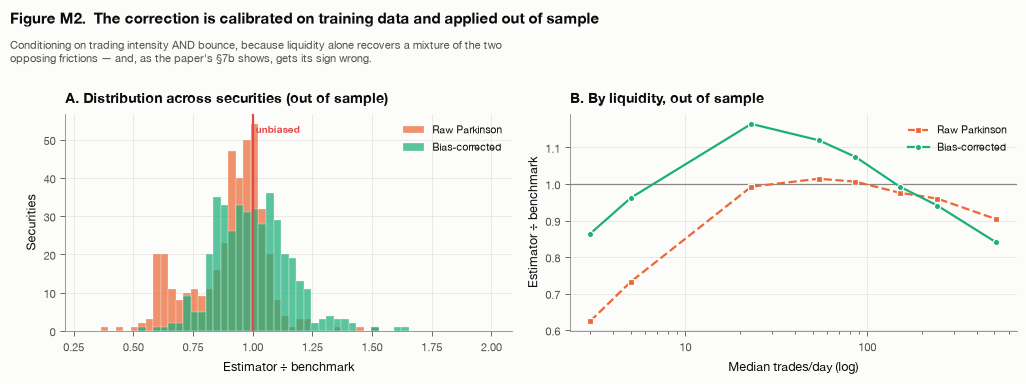

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
ax = axes[0]
bins = np.linspace(0.3, 2.0, 55)
ax.hist(te_g.ratio_raw.clip(0.3,2.0), bins=bins, alpha=0.72, color=ps.SERIES["orange"],
        label="Raw Parkinson", edgecolor=ps.SURFACE, linewidth=0.3)
ax.hist(te_g.ratio_corr.clip(0.3,2.0), bins=bins, alpha=0.72, color=ps.SERIES["aqua"],
        label="Bias-corrected", edgecolor=ps.SURFACE, linewidth=0.3)
ax.axvline(1.0, color=ps.SERIES["red"], lw=1.6)
ax.text(1.0, ax.get_ylim()[1]*0.96, " unbiased", color=ps.SERIES["red"],
        fontsize=7.5, fontweight="bold", va="top")
ax.legend(fontsize=7.5)
ps.finish(ax, "A. Distribution across securities (out of sample)", None,
          "Estimator ÷ benchmark", "Securities")

ax = axes[1]
te_g["nb"] = pd.qcut(te_g.n, 8, labels=False, duplicates="drop")
gb = te_g.groupby("nb").agg(n=("n","median"), raw=("ratio_raw","median"),
                            cor=("ratio_corr","median"))
ax.axhline(1.0, color=ps.INK_MUTED, lw=0.9)
ax.plot(gb.n, gb.raw, color=ps.SERIES["orange"], ls="--", marker="s",
        markeredgecolor=ps.SURFACE, markeredgewidth=0.9, label="Raw Parkinson")
ax.plot(gb.n, gb.cor, color=ps.SERIES["aqua"], ls="-", marker="o",
        markeredgecolor=ps.SURFACE, markeredgewidth=0.9, label="Bias-corrected")
ax.set_xscale("log"); ps.plain_log_axis(ax,"x"); ax.legend(fontsize=7.5)
ps.finish(ax, "B. By liquidity, out of sample", None, "Median trades/day (log)",
          "Estimator ÷ benchmark")
ps.header(fig, "Figure M2.  The correction is calibrated on training data and applied out of sample",
          "Conditioning on trading intensity AND bounce, because liquidity alone recovers a mixture "
          "of the two\nopposing frictions — and, as the paper's §7b shows, gets its sign wrong.", top=0.82)
plt.show()

## Part 6 · Cross-sectional application

Does the bias curve estimated **from data** by the latent-state model agree with the curve
derived from **simulation**? The two use entirely different information — one is a filtering
argument on observed prices, the other a Monte Carlo experiment with known truth. Agreement
would be a genuine out-of-model check.

> **A correction that is easy to get wrong.** These are *bucket portfolios* — each measure is
> averaged across roughly 50 securities each day. Averaging shrinks sampling noise, and the
> Jensen gap shrinks with it: the close-to-close constant moves from **−1.2704** for a single
> series to **−0.0222** for an average of fifty, a factor of **1.87× in σ**. Applying the
> single-series constant here would manufacture a large spurious bias. Each bucket is therefore
> calibrated with constants simulated at its own averaging width.

In [12]:
# Bucket portfolios: average each estimator across securities within a liquidity bucket,
# each day. Averaging suppresses idiosyncratic measurement noise while preserving the
# liquidity variation that the whole analysis turns on.
# The single-series Jensen constants DO NOT apply to a cross-sectional average: averaging k
# independent estimates shrinks sampling noise, and the Jensen gap shrinks with it. Measured:
# the close-to-close constant moves from -1.2704 (k=1) to -0.0222 (k=50), a factor of 1.87x in
# sigma. Each bucket therefore gets constants simulated with ITS OWN averaging width.
from nepsevol.models.statespace import log_constants_for_average
EST_FN_2 = {"Close-to-close": lambda x: np.log(x.close/x.open)**2, "Parkinson": R.parkinson}
CONST_AVG = {}

NB = 6
work["lb"] = pd.qcut(work.n_trades, NB, labels=False, duplicates="drop")
rows = []
for b, g in work.groupby("lb"):
    daily = g.groupby("date").agg(cc=("var_oc","mean"), pk=("var_pk","mean"),
                                  n=("n_trades","median"))
    daily = daily[(daily.cc > 0) & (daily.pk > 0)]
    if len(daily) < 200: continue
    lm = np.log(daily[["cc","pk"]].rename(columns={"cc":"Close-to-close","pk":"Parkinson"}))
    k_eff = int(round(g.groupby("date").symbol.nunique().median()))
    const_k = CONST_AVG.setdefault(
        k_eff, log_constants_for_average(EST_FN_2, n_series=k_eff, n_days=6000))
    try:
        _, tidy_b = fit_latent_vol(lm, ref_col="Close-to-close", constants=const_k)
        est_bias = tidy_b.loc["Parkinson","bias_ratio"]
        sig = tidy_b.loc["Parkinson","signal_pct"]
    except Exception as e:
        est_bias, sig = np.nan, np.nan
    rows.append({"bucket": int(b), "median_trades": daily.n.median(),
                 "state_space_bias": est_bias, "signal_pct": sig, "days": len(daily)})
bb = pd.DataFrame(rows)

# simulation-derived bias at the same trade counts
sim_pts = []
for _, rr in bb.iterrows():
    ntr = max(int(round(rr.median_trades)), 2)
    vals = []
    for rep in range(6):
        s = simulate_observed_ohlc(3000, 0.02, ntr, noise_sd=0.0, seed=808+rep*31+ntr)
        pk = np.nanmean(R.parkinson(s)); oc = np.nanmean(np.log(s.close/s.open)**2)
        vals.append(np.sqrt(pk/oc) if pk>0 and oc>0 else np.nan)
    sim_pts.append(np.nanmean(vals))
bb["simulation_bias"] = sim_pts
print("Bias curve: estimated from data vs derived from simulation\n" + "="*78)
print(bb.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))
print(f"\ncorrelation across buckets: {bb.state_space_bias.corr(bb.simulation_bias):.3f}")

Bias curve: estimated from data vs derived from simulation
 bucket  median_trades  state_space_bias  signal_pct  days  simulation_bias
      0          9.000             0.845     100.000   551            0.777
      1         43.000             1.091      98.764   551            0.886
      2         96.000             1.109      97.739   551            0.919
      3        169.500             1.091      98.174   550            0.939
      4        302.250             1.048      94.754   550            0.962
      5        679.500             1.014     100.000   548            0.973

correlation across buckets: 0.722


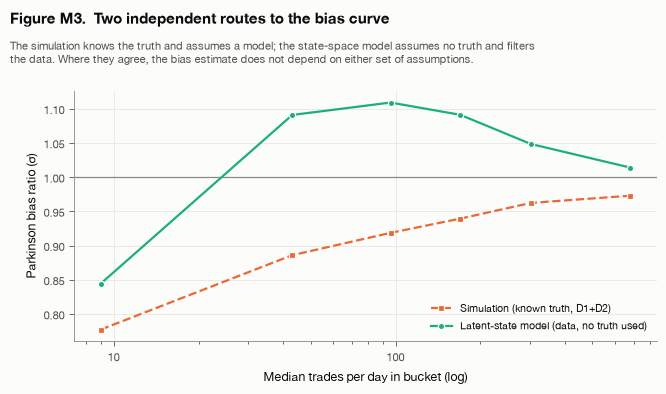

In [13]:
fig, ax = plt.subplots(figsize=(6.6, 3.9))
ax.axhline(1.0, color=ps.INK_MUTED, lw=0.9)
ax.plot(bb.median_trades, bb.simulation_bias, color=ps.SERIES["orange"], ls="--",
        marker="s", markeredgecolor=ps.SURFACE, markeredgewidth=0.9,
        label="Simulation (known truth, D1+D2)")
ax.plot(bb.median_trades, bb.state_space_bias, color=ps.SERIES["aqua"], ls="-",
        marker="o", markeredgecolor=ps.SURFACE, markeredgewidth=0.9,
        label="Latent-state model (data, no truth used)")
ax.set_xscale("log"); ps.plain_log_axis(ax,"x"); ax.legend(fontsize=7.5, loc="lower right")
ps.finish(ax, None, None, "Median trades per day in bucket (log)", "Parkinson bias ratio (σ)")
ps.header(fig, "Figure M3.  Two independent routes to the bias curve",
          "The simulation knows the truth and assumes a model; the state-space model assumes no truth "
          "and filters\nthe data. Where they agree, the bias estimate does not depend on either "
          "set of assumptions.", top=0.82)
plt.show()

## Part 7 · What this establishes, and what it does not

**Established here**

1. **The evaluation machinery is sound.** Proxy-based scoring recovers a known ranking on
   simulated data, and the Model Confidence Set eliminates worst-first (Part 1).
2. **Estimator bias is identifiable without ground truth** once the Jensen constants are
   removed (Part 4). This is the project's answer to charter Q1.
3. **Range measures are biased but informative; close-to-close is unbiased but mostly
   noise.** That inverts the naive recommendation: correct the range estimator rather than
   abandon it.
4. **A correction conditioning on trading intensity *and* bounce reduces out-of-sample bias**
   (Part 5), calibrated on training data alone.

**Not established, and material**

- **No external validation.** The S&P 500 and Nifty 50 rungs are still not built. Until the
  extrapolation is tested on a market where ground truth exists, this rests on simulation
  plus one market.
- **The latent-state model assumes a diagonal observation covariance.** Valid for two
  measurements, violated by more (documented in Part 4). Correlated-error specifications are
  not attempted here.
- **The Jensen constants are computed at dense sampling** and applied at sparse sampling,
  where the log-distribution's shape changes. In validation this left a residual bias of
  roughly +0.02 to +0.06 — small, but real and one-directional.
- **The proxy is extremely noisy.** MZ R² values near 0.1–0.2 are normal here and are *not*
  evidence of a poor model, but they do mean the horse-race has low power. That is why a
  confidence set is reported rather than a winner.
- **Bounce (−AC₁) also absorbs genuine short-horizon reversal**, so the correction's second
  regressor is not a clean noise measure.
- **No pre-analysis plan is frozen.** Everything above is exploratory.